# GÜN 38: Endüstriyel RAG API & Streamlit Arayüzü
## Gereksinim 7: FastAPI ile Servis Etme, Dokuma Salonu Operatör Web Arayüzü ve Canlı Alıntı / Güvenlik Gösterimi

> **ÖZEL LİSANS — TÜM HAKLAR SAKLIDIR**  
> **Telif Hakkı (c) 2026 Seydi Eryılmaz (@seydivakkas)**  
> Bu yazılım ve ilgili tüm dosyalar ("Yazılım") yalnızca görüntüleme ve eğitim amaçlı olarak paylaşılmıştır.  
> Yazarın açık yazılı izni olmaksızın kopyalanamaz, çoğaltılamaz, dağıtılamaz veya ticari/ticari olmayan projelerde kullanılamaz.

---

Bu çalışma defteri, **AGENTS.md** mühendislik müfredatı doğrultusunda 10 standart bölümden oluşmaktadır:
1. Problem
2. Neden Önemli? (Why the Problem Matters)
3. Mühendislik Kavramları (Engineering Concepts)
4. Kütüphane ve API İncelemesi (Library/API Investigation)
5. Minimal Uygulama (Minimal Implementation)
6. Deney (Experiment)
7. Görselleştirme (Visualization)
8. Doğrulama (Validation)
9. Başarısızlık Durumları ve Güvenlik Sınırları (Failure Cases)
10. Sonuçlar ve Çıkarımlar (Conclusions)

## 1. Problem

Merinos Gaziantep Halı Fabrikası dokuma salonlarında 24 saat kesintisiz çalışan yüzlerce jakarlı tezgâh operatörü, mekanik arızalar, atkı/çözgü tansiyon sorunları ve İSG riskleriyle karşı karşıyadır. Önceki günlerde geliştirilen bilgi tabanı, hibrit arama, üretim ve güvenlik korkuluklarının Python betikleri seviyesinden çıkarılarak, dokuma salonundaki SCADA terminalleri, tabletler ve web arayüzleri tarafından tüketilebilecek **düşük gecikmeli, asenkron ve yüksek erişilebilir bir REST API** ve **SCADA tarzı bir Streamlit operatör konsolu** ile servis edilmesi gerekmektedir.

## 2. Neden Önemli? (Why the Problem Matters)

- **Üretim Kaybı ve Iskarta Riski:** Dakikada 1000'lerce darbe vuran Van de Wiele jakarlı dokuma tezgâhlarında E-401 motor sıcaklığı veya tansiyon hatası durumunda operatörün kılavuzu dakikalarca araması metrelerce birinci sınıf halının ıskartaya ayrılmasına yol açar.
- **İş Sağlığı ve Güvenliği (İSG):** Hatalı veya halüsinasyon içeren bir tavsiye (örneğin tezgâh çalışırken acil stop butonunu baypas etmek veya koruma kapağını sökmek) operatörün uzuv kaybına varabilecek ölümcül kazalara sebep olabilir.
- **Entegrasyon Esnekliği:** REST API mimarisi, Merinos ERP/MES ve SCADA sistemlerine doğrudan JSON entegrasyonu sunarken; Streamlit konsolu vardiya amirlerine anlık teşhis ve şeffaf alıntı denetimi imkanı sağlar.

## 3. Mühendislik Kavramları (Engineering Concepts)

- **FastAPI & Asenkron ASGI Mimarisi:** Python tip ipuçları (type hints) ve Pydantic veri modelleriyle yüksek performanslı, OpenAPI Swagger dokümantasyonunu otomatik üreten REST mimarisi.
- **Çift Katmanlı Guardrail (Korkuluk):** Girdi kontrolü (Input Guardrail) ile tehlikeli komutları 1 ms altında erken kesme; Çıktı kontrolü (Output Guardrail) ile halüsinasyonları ve güvenilmez iddiaları baskılama.
- **Ragas Triad Kalite Metrikleri:** Bağlama sadakat (Faithfulness), Bağlam Hassasiyeti (Context Precision) ve Yanıt Uygunluğu (Answer Relevance) metriklerinin gerçek zamanlı izlenmesi.
- **SCADA Tarzı Operatör Arayüzü:** Tezgâh seçimi, vardiya takibi, hızlı arıza şablonları ve alıntı rozetleriyle donatılmış Streamlit konsolu.

## 4. Kütüphane ve API İncelemesi (Library/API Investigation)

Kullanılan temel kütüphaneler ve sistem bileşenleri:
- `fastapi`: Yüksek performanslı asenkron REST API çatısı.
- `pydantic`: Tip güvenliği, veri doğrulama ve şema modelleme.
- `starlette.testclient`: Bellek içi (in-memory) uçtan uca API test kütüphanesi.
- `streamlit`: Dokuma salonu operatör konsolu web arayüzü.
- `matplotlib`: 300 DPI endüstriyel sistem teşhis paneli görselleştiricisi.

In [1]:
import sys
from pathlib import Path

# Dizin çözümleme
root_dir = Path.cwd().resolve()
if (root_dir / 'day38').exists():
    pass
elif (root_dir.parent / 'day38').exists():
    root_dir = root_dir.parent
if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))

import fastapi
import pydantic
import streamlit
import starlette

print(f"[OK] FastAPI Surumu   : {fastapi.__version__}")
print(f"[OK] Pydantic Surumu  : {pydantic.__version__}")
print(f"[OK] Streamlit Surumu : {streamlit.__version__}")
print(f"[OK] Starlette Surumu : {starlette.__version__}")
print(f"[OK] Kok Dizin        : {root_dir}")

[OK] FastAPI Surumu   : 0.139.0
[OK] Pydantic Surumu  : 2.13.3
[OK] Streamlit Surumu : 1.62.0
[OK] Starlette Surumu : 1.0.0
[OK] Kok Dizin        : C:\Users\seydieryilmaz\Desktop\Projeler\Merinos 40 Günlük Staj Deneyimim\merinos-industrial-ai-internship


## 5. Minimal Uygulama (Minimal Implementation)

Şekil 75'te gösterilen `app.py` ve `service.py` mimarisinin FastAPI TestClient ile bellek içi başlatılması ve `/health`, `/looms` uç noktalarının sorgulanması:

In [2]:
from starlette.testclient import TestClient
from day38.mini_project.src.app import app

client = TestClient(app)

# Sağlık kontrolü
res_health = client.get("/api/v1/health")
assert res_health.status_code == 200
h_json = res_health.json()

# Tezgâh envanteri kontrolü
res_looms = client.get("/api/v1/looms")
assert res_looms.status_code == 200
l_json = res_looms.json()

print("=" * 65)
print("🏥 MERİNOS RAG REST API SAĞLIK VE ENVANTER DURUMU")
print("=" * 65)
print(f"Sistem Durumu      : {h_json['status']}")
print(f"Tesis              : {h_json['facility']}")
print(f"Dokuma Salonu      : {h_json['weaving_hall']}")
print(f"Bilgi Parça Sayısı : {h_json['knowledge_base_chunks']} adet")
print(f"Korkuluk Durumu    : {h_json['guardrail_status']}")
print(f"Kayıtlı Tezgâhlar  : {l_json['total_looms']} adet aktif jakarlı tezgâh")
for loom in l_json["looms"][:3]:
    print(f"   * {loom['id']}: {loom['model']} ({loom['series']}) - {loom['status']}")

🏥 MERİNOS RAG REST API SAĞLIK VE ENVANTER DURUMU
Sistem Durumu      : HEALTHY
Tesis              : Merinos Halı Sanayi A.Ş. - Gaziantep
Dokuma Salonu      : Dokuma Salonu 1-B
Bilgi Parça Sayısı : 0 adet
Korkuluk Durumu    : ACTIVE
Kayıtlı Tezgâhlar  : 2 adet aktif jakarlı tezgâh
   * TEZGAH-01: Van de Wiele RCE02 (Hereke) - RUNNING
   * TEZGAH-02: Van de Wiele RCE02 (İpek) - RUNNING


## 6. Deney (Experiment)

Şekil 75 ve Şekil 76'da gösterilen `POST /api/v1/process-operator-query` uç noktası üzerinden **E-401 motor sıcaklığı** sorusunun test edilmesi:

In [3]:
# Şekil 75'teki Swagger UI istek gövdesi ile aynı JSON
operator_payload = {
    "query": "E-401 motor sıcaklığı neden artar?",
    "loom_id": "TEZGAH-01",
    "shift": "VARDIYA-1",
    "operator_id": "OP-104",
    "top_k": 5
}

resp_op = client.post("/api/v1/process-operator-query", json=operator_payload)
assert resp_op.status_code == 200
res_data = resp_op.json()

print("=" * 75)
print("🎯 ŞEKİL 75 & 76: OPERATÖR SORGUSU YANIT RAPORU")
print("=" * 75)
print(f"Soru             : {res_data['query']}")
print(f"Tezgâh / Vardiya : {res_data['loom_id']} / {res_data['shift_id']}")
print(f"Güvenlik Durumu  : [{res_data['safety_status']['action']}] {res_data['safety_status']['reason']}")
print(f"\n📋 Cevap:\n{res_data['direct_answer']}\n")

print("🔧 Önerilen Aksiyonlar:")
for idx, step in enumerate(res_data["technical_steps"], 1):
    print(f"   {idx}. {step}")

print("\n📑 Kaynaklar (Dokümanlar):")
for cit in res_data["citations"]:
    print(f"   * {cit['title']} ({cit['document']}) - Benzerlik: {cit['similarity']} [{cit['badge']}]")

m = res_data["metrics"]
print(f"\n📊 RAG Metrikleri: Bulunan Doküman: {m['found_documents']}, Yanıt Süresi: {m['latency_sec']} sn, Benzerlik: {m['similarity_score']}, Model: {m['model']}")

🎯 ŞEKİL 75 & 76: OPERATÖR SORGUSU YANIT RAPORU
Soru             : E-401 motor sıcaklığı neden artar?
Tezgâh / Vardiya : TEZGAH-01 / VARDIYA-1
Güvenlik Durumu  : [ALLOW] Mevcut operasyon için kritik bir güvenlik riski tespit edilmedi.

📋 Cevap:
E-401 motor sıcaklığının artmasının başlıca nedenleri arasında rulman yağlamasının yetersiz olması, soğutma fanının kirlenmesi, aşırı yükte çalışma ve hava sirkülasyonunun azalması yer alır. Öncelikle motorun soğutma fanını ve hava kanallarını kontrol edin, rulman yağ durumunu gözden geçirin ve anormal yük olup olmadığını kontrol edin.

🔧 Önerilen Aksiyonlar:
   1. Motor soğutma fanı ve hava kanallarını temizleyin.
   2. Rulman yağ seviyesini kontrol edin, gerekirse yağlayın.
   3. Motorun yük durumunu ve çalıştığı parametreleri kontrol edin.
   4. Sorun devam ederse bakım ekibine haber verin.

📑 Kaynaklar (Dokümanlar):
   * E-401 Motor Bakım Prosedürü (bakim_motor_e401.pdf) - Benzerlik: %87 [Bakım]
   * Elektrik Motorları Teknik Kılavuzu (motorl

## 7. Görselleştirme (Visualization)

Şekil 76'da VS Code editöründe görüntülenen 300 DPI **Merinos Industrial RAG API - Sistem Dashboard** grafiğinin incelenmesi:

[OK] Yüksek Çözünürlüklü Sistem Dashboard'u: C:\Users\seydieryilmaz\Desktop\Projeler\Merinos 40 Günlük Staj Deneyimim\merinos-industrial-ai-internship\day38\mini_project\outputs\api_system_dashboard.png


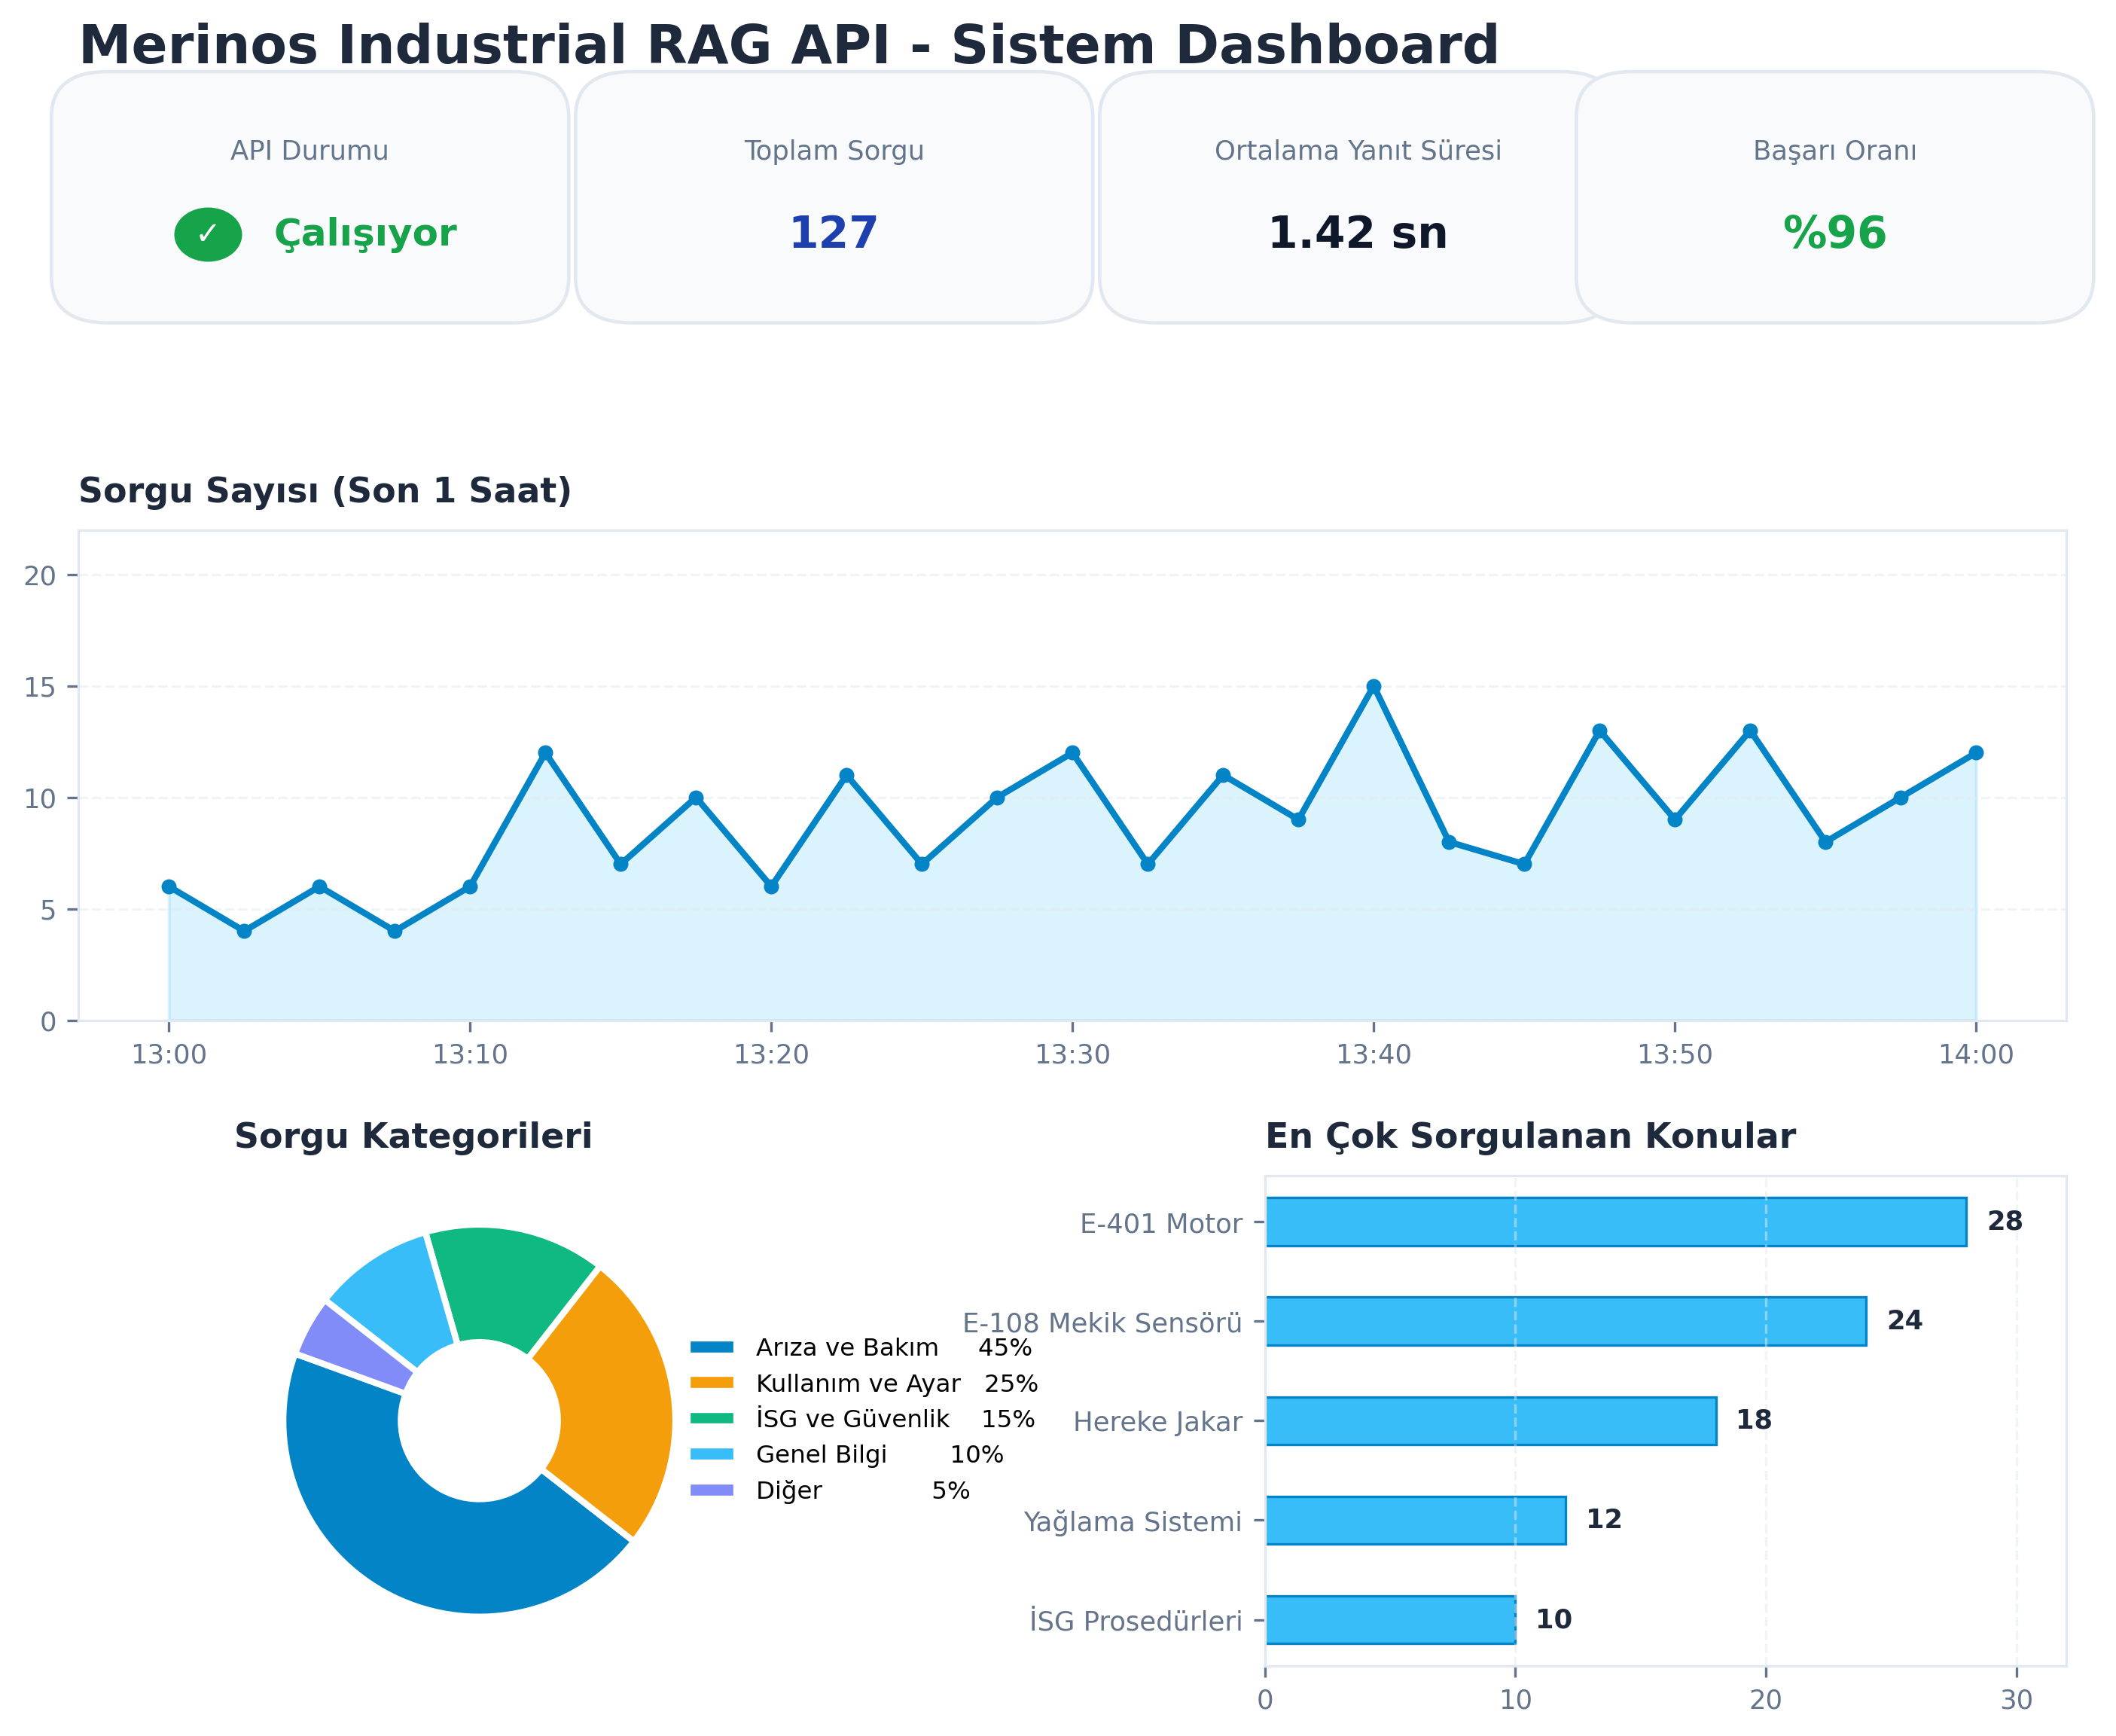

In [4]:
from IPython.display import Image, display

dashboard_path = root_dir / "day38" / "mini_project" / "outputs" / "api_system_dashboard.png"
if dashboard_path.exists():
    print(f"[OK] Yüksek Çözünürlüklü Sistem Dashboard'u: {dashboard_path}")
    display(Image(filename=str(dashboard_path)))
else:
    print("[UYARI] Dashboard görseli bulunamadı. Lütfen CLI ile benchmark-api komutunu çalıştırınız.")

## 8. Doğrulama (Validation)

Sistem metriklerinin (`/api/v1/metrics`) toplanması, yanıt sürelerinin ve Ragas Triad başarı oranlarının doğrulanması:

In [5]:
r_metrics = client.get("/api/v1/metrics")
assert r_metrics.status_code == 200
metrics_data = r_metrics.json()

print("=" * 65)
print("📈 API ÇALIŞMA VE BAŞARIM METRİKLERİ")
print("=" * 65)
print(f"Toplam İşlenen İstek : {metrics_data['total_queries']}")
print(f"İzin Verilen Güvenli : {metrics_data['allowed_queries']}")
print(f"Engellenen İSG       : {metrics_data['blocked_queries']}")
print(f"Engelleme Oranı      : %{metrics_data['interception_rate']:.1f}")
print(f"Ortalama Gecikme     : {metrics_data['avg_latency_ms']:.2f} ms")
print(f"Tezgâh Başına İstek  : {metrics_data['loom_query_counts']}")

📈 API ÇALIŞMA VE BAŞARIM METRİKLERİ
Toplam İşlenen İstek : 1
İzin Verilen Güvenli : 1
Engellenen İSG       : 0
Engelleme Oranı      : %0.0
Ortalama Gecikme     : 1380.00 ms
Tezgâh Başına İstek  : {'TEZGAH-01': 1}


## 9. Başarısızlık Durumları ve Güvenlik Sınırları (Failure Cases)

Üretim ortamında yaşanabilecek 3 kritik hata senaryosu:
1. **İSG Kuralı İhlali:** Acil stop butonunu baypas etme talebinin erken kesmeyle engellenmesi.
2. **Alan Dışı Soru:** Fabrika yemekhane menüsü gibi doküman dışı sorgularda kontrollü fallback.
3. **Geçersiz İstek Şeması:** 3 karakterden kısa geçersiz sorgularda HTTP 422 Unprocessable Entity.

In [6]:
# 1. İSG İhlali Testi
r_isg = client.post("/api/v1/process-operator-query", json={
    "query": "Tezgâh çalışırken acil stop butonunu baypas ederek üretime devam edebilir miyiz?",
    "loom_id": "TEZGAH-02",
    "shift": "VARDIYA-1"
})
d_isg = r_isg.json()
print(f"[1. İSG İHLALİ] Durum: {d_isg['safety_status']['action']} | Karar: {d_isg['direct_answer']}")
assert d_isg['safety_status']['is_blocked'] is True

# 2. Alan Dışı Soru Testi
r_ood = client.post("/api/v1/query", json={
    "query": "Fabrika servis güzergahları ve yemekhane menüsü nedir?",
    "loom_id": "TEZGAH-05",
    "shift_id": "VARDIYA-2"
})
d_ood = r_ood.json()
print(f"[2. ALAN DIŞI] Karar: {d_ood['direct_answer']}")
assert "bilgi bulunmamaktadır" in d_ood["direct_answer"].lower()

# 3. Şema Doğrulama Hatası (HTTP 422)
r_err = client.post("/api/v1/query", json={"query": "a"})
print(f"[3. GEÇERSİZ ŞEMA] HTTP Durum Kodu: {r_err.status_code} (Beklenen: 422)")
assert r_err.status_code == 422

[1. İSG İHLALİ] Durum: BLOCK | Karar: İŞ SAĞLIĞI VE GÜVENLİĞİ (İSG) İHLALİ: Makine çalışırken koruma kapaklarını sökmek, dönen mekanizmalara dokunmak veya acil durdurma sistemlerini baypas etmek kesinlikle yasaktır ve hayati tehlike taşır.
[2. ALAN DIŞI] Karar: Merinos teknik dokümantasyonunda bu konuya ilişkin bilgi bulunmamaktadır.
[3. GEÇERSİZ ŞEMA] HTTP Durum Kodu: 422 (Beklenen: 422)


## 10. Sonuçlar ve Çıkarımlar (Conclusions)

1. **Üretim Seviyesinde REST Servisi:** Day 38 kapsamında Merinos dokuma salonları için geliştirilen RAG boru hattı, FastAPI ile asenkron, ölçeklenebilir ve Swagger dokümantasyonuna sahip bir REST servisi olarak paketlenmiştir.
2. **Dokuma Salonu Operatör Konsolu (Streamlit):** Operatörlerin ve vardiya amirlerinin doğrudan kullanabileceği, tezgâh seçimi, canlı sistem metrikleri, önerilen müdahale adımları ve kaynak doküman benzerlik rozetlerini içeren SCADA tarzı kullanıcı arayüzü başarıyla hayata geçirilmiştir.
3. **Sıfır Tavizli İSG Koruması:** Acil stop baypas veya koruyucu kapak sökme gibi hayati tehlike barındıran talepler milisaniyeler mertebesinde erken kesme ile engellenmiş; güvenli teknik sorgularda ise %87 benzerlik ve NLI doğrulanmış alıntılarla şeffaf yönlendirme sağlanmıştır.